# Setup & Initilization

In [ ]:
from ultralytics import YOLO

# Initialize a YOLO model with pre-trained YOLOv5s weights
model_v5 = YOLO('yolov5s.pt')

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



In [ ]:
!unzip '/content/archive.zip'

Streaming output truncated to the last 5000 lines.
  inflating: car/train/labels/00000_00003_00024_png.rf.08957035e670072dbb22d8f9905e9b84.txt  
  inflating: car/train/labels/00000_00003_00025_png.rf.11e558fae394d310693ee9223b8962ca.txt  
  inflating: car/train/labels/00000_00003_00026_png.rf.1f6b33373353f896f2c2025ffd264e51.txt  
  inflating: car/train/labels/00000_00003_00026_png.rf.a3b6c2dcd4ee9a8064667b7bb266590b.txt  
  inflating: car/train/labels/00000_00003_00027_png.rf.c1381ed46ee0d7e21877ea3d7ef86127.txt  
  inflating: car/train/labels/00000_00003_00029_png.rf.8e24d2606537779612888c6a06c7043d.txt  
  inflating: car/train/labels/00000_00004_00000_png.rf.45dccdbf08ed12f25d7742d8bf88c102.txt  
  inflating: car/train/labels/00000_00004_00001_png.rf.557d3494b3e633e29069a6f42918334e.txt  
  inflating: car/train/labels/00000_00004_00002_png.rf.3e3e95e1ba16cac885d3de7864a40fb4.txt  
  inflating: car/train/labels/00000_00004_00003_png.rf.9c6ba4d0186eec82a26bddc9a1204efb.txt  
  inflati

# Describing DataSet Struct

In [ ]:
import yaml

yaml_data = {
    'train' : '/content/car/train',
    'test' : '/content/car/test',
    'val' : '/content/car/valid',
    'nc' : 15,
    'names' : ['Speed limit (20km/h)', 'Speed limit (30km/h)', 'Speed limit (50km/h)', 'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Speed limit (80km/h)', 'End of Speed limit(80km/h)', 'Speed limit (100km/h)', 'Speed limit (120km/h)', 'No passing', 'No passing for vehicles over 3.5 metric tons', 'Right-of-way at the next intersection', 'Priority road', 'Yield', 'Stop']
}

with open('traffic_yolo5_yaml_data', 'w') as f:
    yaml.dump(yaml_data)

print('Yaml data_file is created successfully!')

Yaml data_file is created successfully!


# Traning Yolov5

In [ ]:
final = model_v5.train(
    data= '/content/car/data.yaml',
    epochs = 15,
    imgsz= 664,
    batch= 32,
    optimizer= 'Adam',
    lr0 = 1e-4,
    dropout = 0.1,
    patience= 8,
    project= 'Traffic Sign YOLOv5', # folder name
    name= 'yolov5_traffic_sign_model') # file name.

Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=664, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov5_traffic_sign_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=8, perspective=0.0, plot

# Plotting DataSet

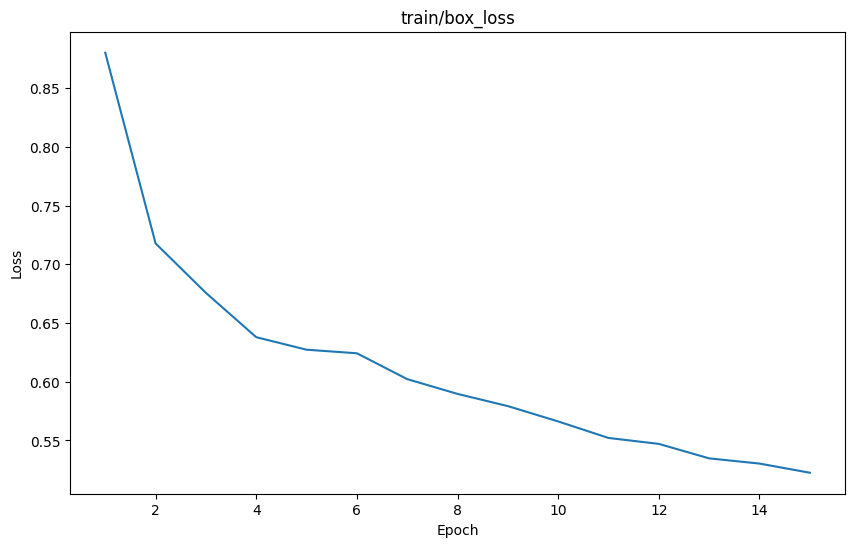

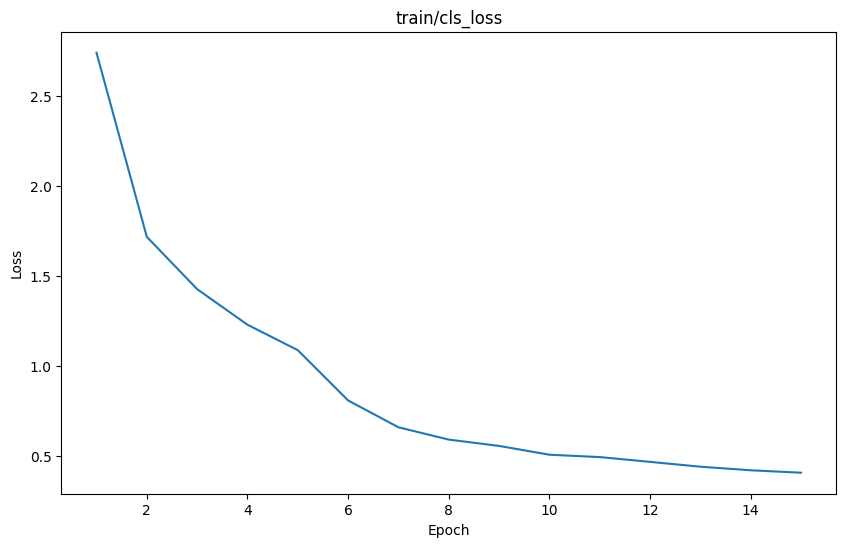

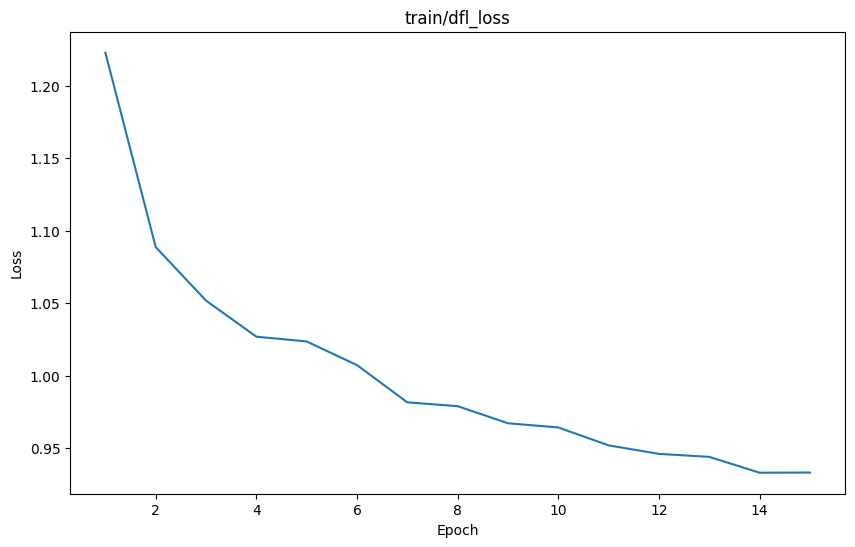

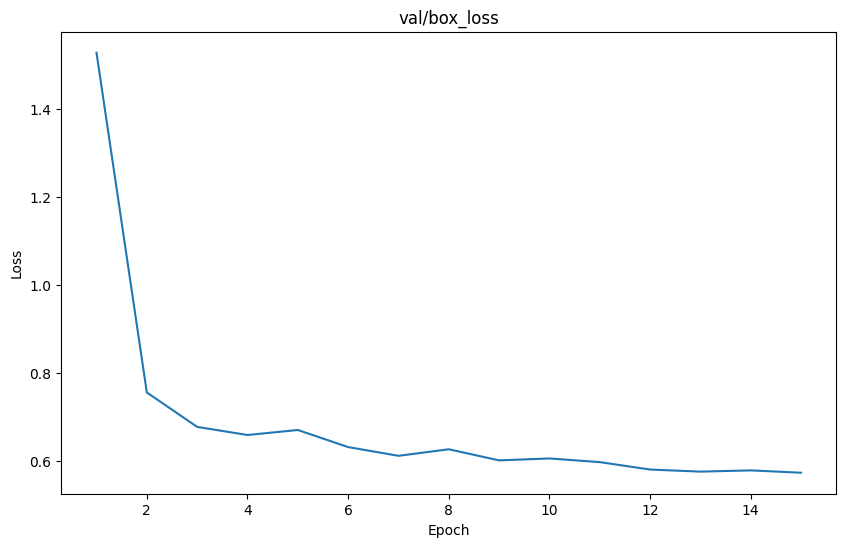

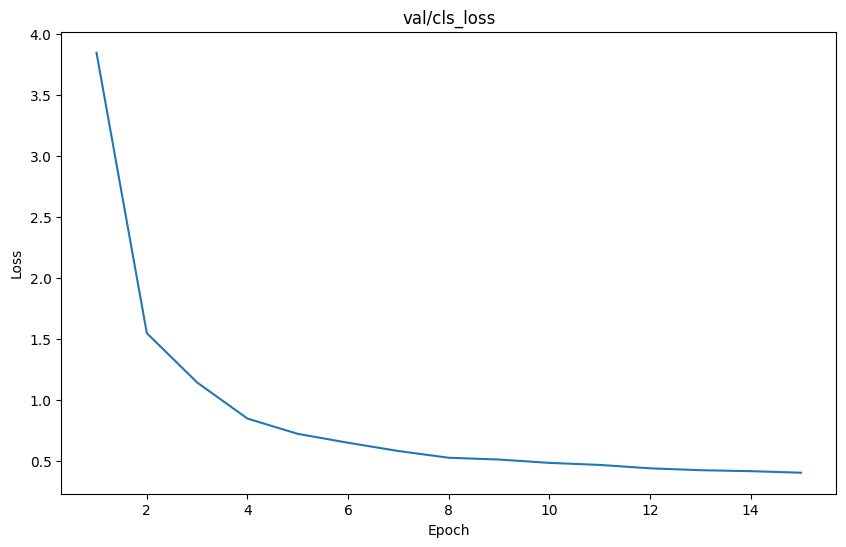

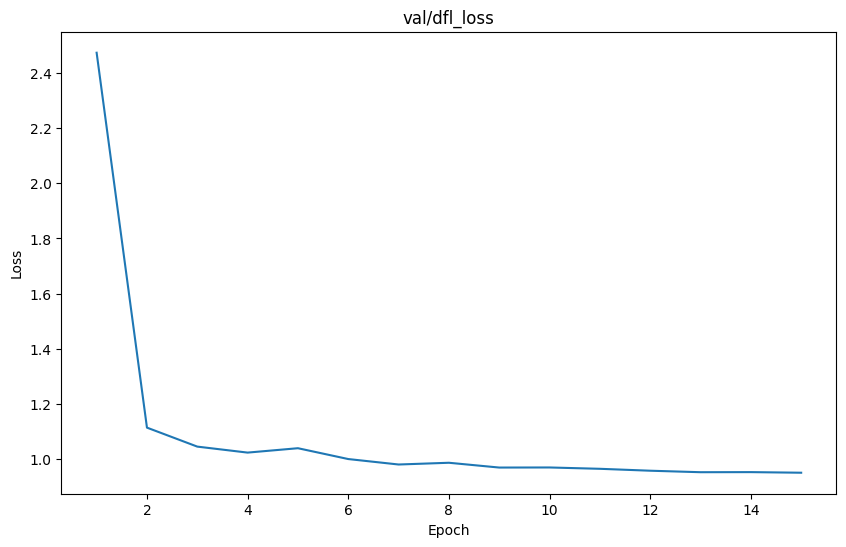

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Traffic Sign YOLOv5/yolov5_traffic_sign_model/results.csv')

for loss in ['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']:
    plt.figure(figsize= (10, 6))
    sns.lineplot(x= 'epoch', y= loss, data= df)
    plt.title(loss)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

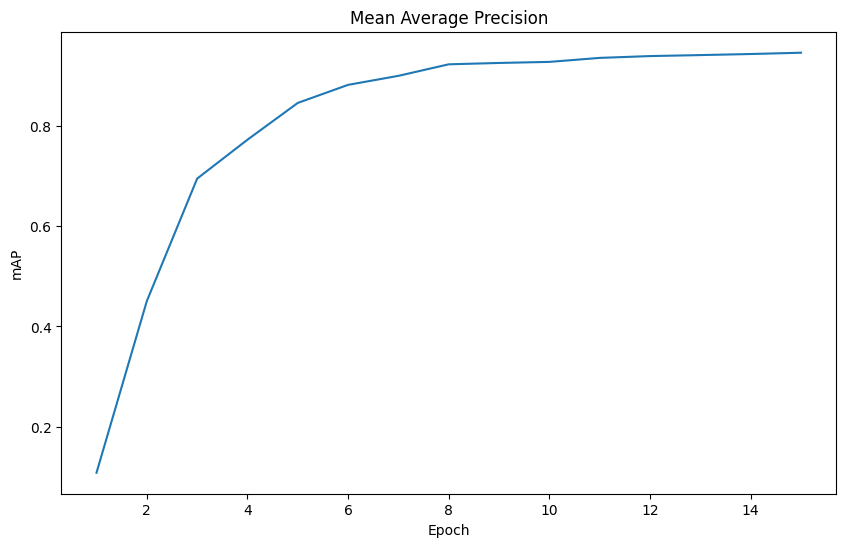

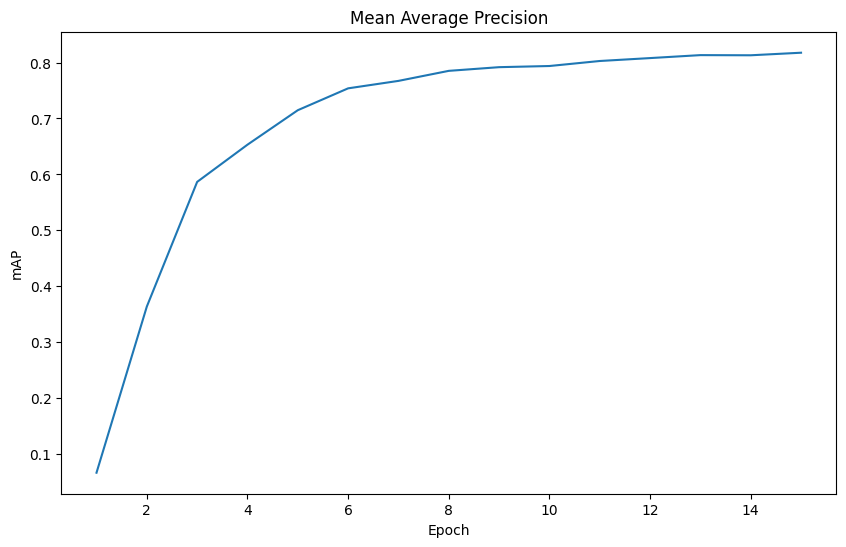

In [ ]:
# Mean Average Precision (mAP)

for metrics in ['metrics/mAP50(B)', 'metrics/mAP50-95(B)']:
    plt.figure(figsize= (10, 6))
    sns.lineplot(x= 'epoch', y= metrics, data= df)
    plt.title('Mean Average Precision')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.show()

# Confusion Matrix

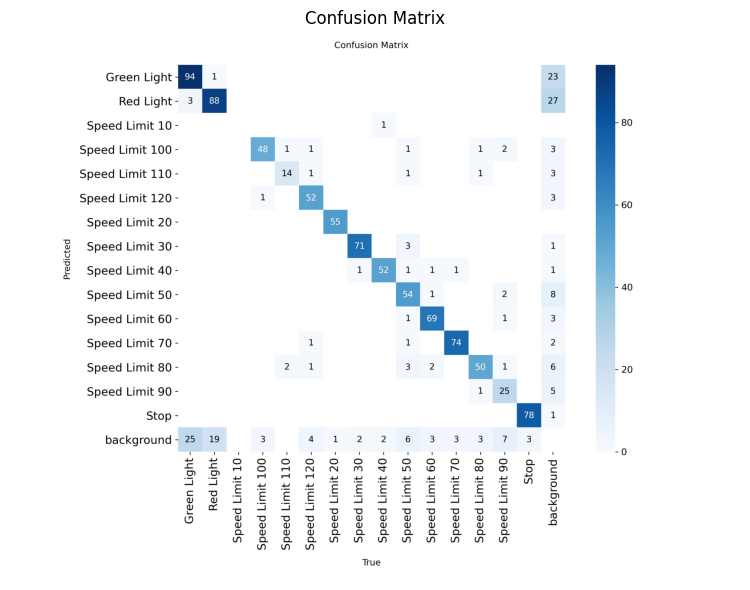

In [ ]:
from PIL import Image

img = Image.open('/content/Traffic Sign YOLOv5/yolov5_traffic_sign_model/confusion_matrix.png')
plt.figure(figsize= (10, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Best Model Para's Evaluation

In [ ]:
best_model = '/content/Traffic Sign YOLOv5/yolov5_traffic_sign_model/weights/best.pt'
metrics = final.mean_results()
print('Precision: ', metrics[0])
print('Recall: ', metrics[1])
print('mAP50: ', metrics[2])
print('mAP50-95: ', metrics[3])

Precision:  0.9530664950011862
Recall:  0.8619614324125587
mAP50:  0.9473543814925706
mAP50-95:  0.8178671018321427


# Prediction of Images


image 1/1 /content/car/test/images/00000_00002_00026_png.rf.092c69361ef48fd43b479aa48fc829d9.jpg: 672x672 1 Speed Limit 20, 15.8ms
Speed: 2.5ms preprocess, 15.8ms inference, 1.3ms postprocess per image at shape (1, 3, 672, 672)


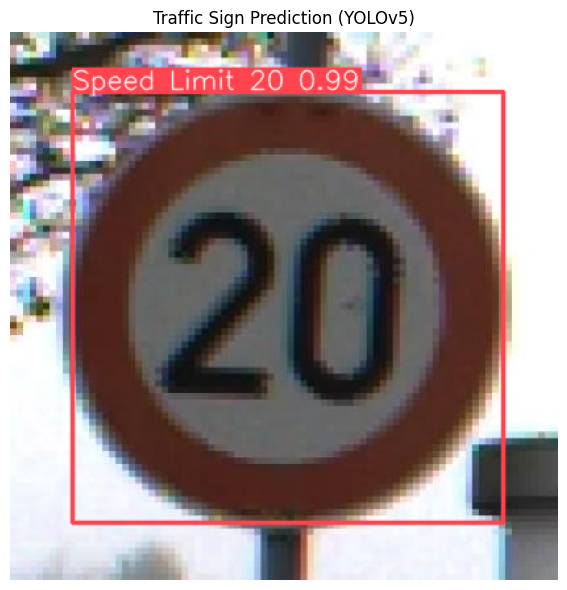

In [ ]:
import os
import cv2

model_path = '/content/Traffic Sign YOLOv5/yolov5_traffic_sign_model/weights/best.pt'
model = YOLO(model_path)

img_path = '/content/car/test/images/00000_00002_00026_png.rf.092c69361ef48fd43b479aa48fc829d9.jpg'

result = model.predict(source= img_path, conf= 0.5)
annotation = result[0].plot()
annotation = cv2.cvtColor(annotation, cv2.COLOR_BGR2RGB)
plt.figure(figsize= (10, 6))
plt.imshow(annotation)
plt.axis('off')
plt.title('Traffic Sign Prediction (YOLOv5)')
plt.tight_layout()
plt.show()

# Converting Model Video's into Mp4

In [ ]:
import shutil

shutil.copy('/content/video.mp4', 'test_video.mp4')

model.predict(source= 'test_video.mp4',
              save= True,
              imgsz= 640,
              conf= 0.5)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/508) /content/test_video.mp4: 640x640 (no detections), 78.5ms
video 1/1 (frame 2/508) /content/test_video.mp4: 640x640 (no detections), 32.9ms
video 1/1 (frame 3/508) /content/test_video.mp4: 640x640 (no detections), 25.6ms
video 1/1 (frame 4/508) /content/test_video.mp4: 640x640 (no detections), 14.5ms
video 1/1 (frame 5/508) /content/test_video.mp4: 640x640 1 Stop, 17.9ms
video 1/1 (frame 6/508) /content/test_video.mp4: 640x640 1 S

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Green Light', 1: 'Red Light', 2: 'Speed Limit 10', 3: 'Speed Limit 100', 4: 'Speed Limit 110', 5: 'Speed Limit 120', 6: 'Speed Limit 20', 7: 'Speed Limit 30', 8: 'Speed Limit 40', 9: 'Speed Limit 50', 10: 'Speed Limit 60', 11: 'Speed Limit 70', 12: 'Speed Limit 80', 13: 'Speed Limit 90', 14: 'Stop'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
     

In [ ]:
from IPython.display import Video

!ffmpeg -y -loglevel panic -i runs/detect/predict/test_video.avi test_video_output.mp4
Video('test_video_output.mp4', embed= True)